# Satellite–Central Cross-Correlation
Compute the cross-correlation $\xi_{\mathrm{sat,cen}}(r)$ between satellite and central galaxies from GALFORM galaxies.hdf5 outputs.

## Import Libraries

In [ ]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import DEFAULT_RBINS, get_snapshot_redshift
from galform_analysis.analysis.correlation import satellite_central_cross_correlation

project_root = Path.cwd().resolve().parents[1]
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11

base_dir = Path('/cosma5/data/durham/dc-hick2/Tau0_Investigation/Galform_Out_Default/L800/lc16.newmg')

## Cross-correlation for a single redshift and subvolume

In [2]:
example_snapshot = 'iz207'
example_ivol = 1
satellite_stellar_mass_min = 1e9  # Msun/h
central_stellar_mass_min = 1e9
host_halo_mass_min = 1e9

cross = satellite_central_cross_correlation(
    base_dir / example_snapshot,
    example_ivol,
    rbins=DEFAULT_RBINS,
    nthreads=4,
    satellite_stellar_mass_min=satellite_stellar_mass_min,
    central_stellar_mass_min=central_stellar_mass_min,
    host_halo_mass_min=host_halo_mass_min,
)

z_val = cross.attrs.get('z')
if z_val is None:
    z_val = get_snapshot_redshift(example_snapshot)
z_label = f"{z_val:.3f}" if z_val is not None else "n/a"

print(
    f"Loaded cross-correlation for {cross.attrs['iz']} (z={z_label}), ",
    f"ivol={cross.attrs['ivol']}; N_sat={cross.attrs['n_sat']}, N_cen={cross.attrs['n_cen']}.",
)

Loaded cross-correlation for iz207 (z=0.496),  ivol=1; N_sat=1938, N_cen=4054.


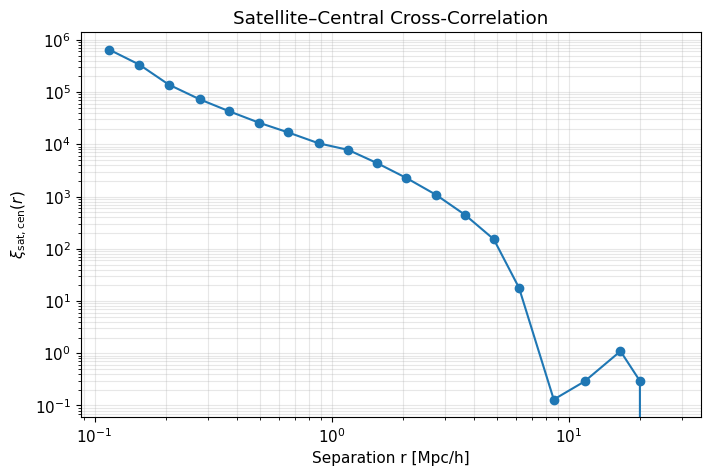

In [ ]:
r = cross['r'].values
xi = cross['xi'].values
valid = np.isfinite(xi) & (xi > -1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(r[valid], xi[valid], 'o-')
ax.set_xlabel('Separation r [Mpc/h]')
ax.set_ylabel(r'$\xi_{\mathrm{sat,cen}}(r)$')
ax.set_title('Satellite-Central Cross-Correlation')
ax.grid(True, alpha=0.3, which='both')
plt.show()

## Compare two redshifts

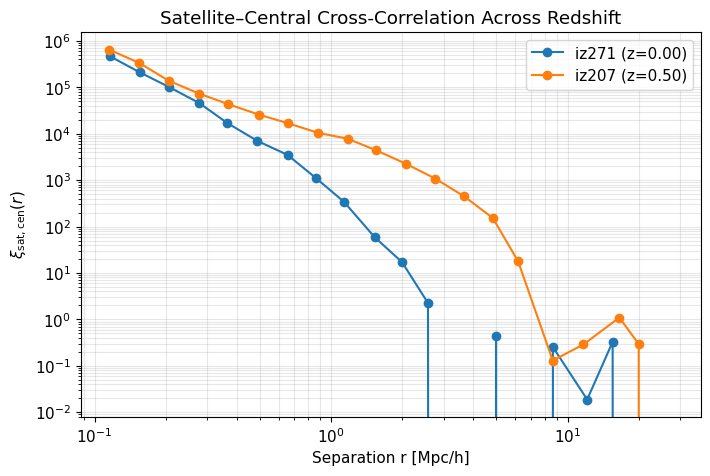

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for snapshot in ['iz271', 'iz207']:
    res = satellite_central_cross_correlation(
        base_dir / snapshot,
        example_ivol,
        rbins=DEFAULT_RBINS,
        nthreads=4,
        satellite_stellar_mass_min=satellite_stellar_mass_min,
        central_stellar_mass_min=central_stellar_mass_min,
        host_halo_mass_min=host_halo_mass_min,
    )
    if res is None:
        print(f"Skipped {snapshot}: no data")
        continue
    r = res['r'].values
    xi = res['xi'].values
    valid = np.isfinite(xi) & (xi > -1)
    if not np.any(valid):
        print(f"Skipped {snapshot}: no finite xi")
        continue
    z_val = res.attrs.get('z')
    if z_val is None:
        z_val = get_snapshot_redshift(snapshot)
    z_label = f"{z_val:.2f}" if z_val is not None else "n/a"
    ax.loglog(r[valid], xi[valid], 'o-', label=f"{snapshot} (z={z_label})")

ax.set_xlabel('Separation r [Mpc/h]')
ax.set_ylabel(r'$\xi_{\mathrm{sat,cen}}(r)$')
ax.set_title('Satellite-Central Cross-Correlation Across Redshift')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.show()

## Cross-correlation across multiple redshifts

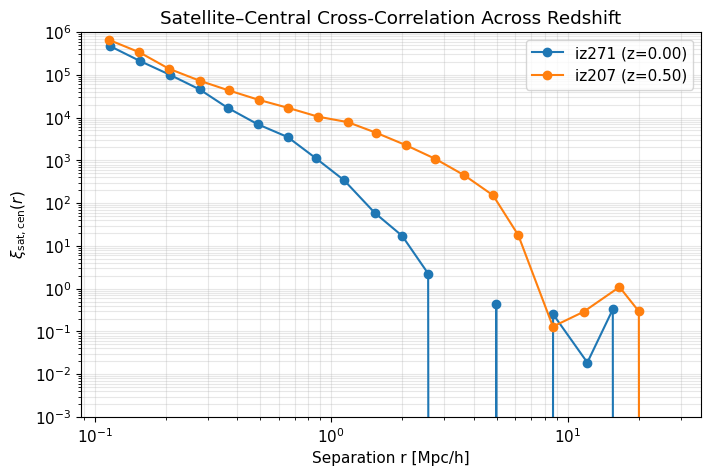

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for snapshot in ['iz271', 'iz207']:
    res = satellite_central_cross_correlation(
        base_dir / snapshot,
        example_ivol,
        rbins=DEFAULT_RBINS,
        nthreads=4,
        satellite_stellar_mass_min=satellite_stellar_mass_min,
        central_stellar_mass_min=central_stellar_mass_min,
        host_halo_mass_min=host_halo_mass_min,
    )
    if res is None:
        print(f"Skipped {snapshot}: no data")
        continue
    r = res['r'].values
    xi = res['xi'].values
    valid = np.isfinite(xi) & (xi > -1)
    if not np.any(valid):
        print(f"Skipped {snapshot}: no finite xi")
        continue
    z_val = res.attrs.get('z')
    if z_val is None:
        z_val = get_snapshot_redshift(snapshot)
    z_label = f"{z_val:.2f}" if z_val is not None else "n/a"
    ax.loglog(r[valid], xi[valid], 'o-', label=f"{snapshot} (z={z_label})")

ax.set_xlabel('Separation r [Mpc/h]')
ax.set_ylabel(r'$\xi_{\mathrm{sat,cen}}(r)$')
ax.set_title('Satellite-Central Cross-Correlation Across Redshift')
ax.legend()
ax.set_ylim(1e-3, 1e6)
ax.grid(True, alpha=0.3, which='both')
plt.show()

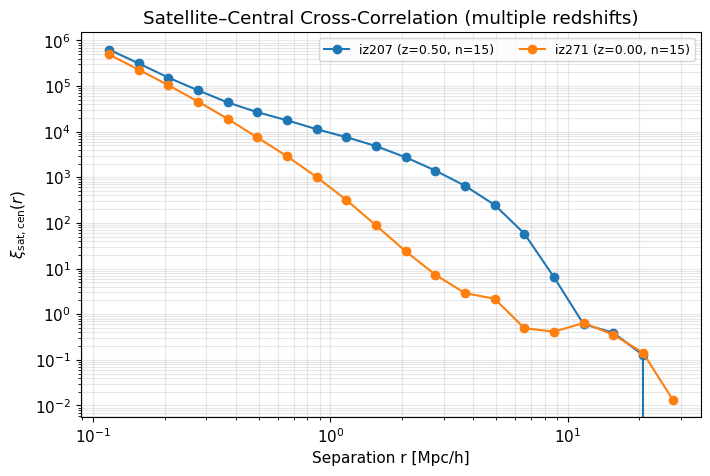

In [ ]:
snapshots = ['iz207', 'iz271']  # ['iz82', 'iz100', 'iz120', 'iz207', 'iz271']
ivols = list(range(0, 15))  # Independent samples to combine; adjust to available ivols.
r_ref = 0.5 * (DEFAULT_RBINS[:-1] + DEFAULT_RBINS[1:])

fig, ax = plt.subplots(figsize=(8, 5))

for snapshot in snapshots:
    xi_stack = []
    n_used = 0
    for ivol in ivols:
        res = satellite_central_cross_correlation(
            base_dir / snapshot,
            ivol,
            rbins=DEFAULT_RBINS,
            nthreads=4,
            satellite_stellar_mass_min=satellite_stellar_mass_min,
            central_stellar_mass_min=central_stellar_mass_min,
            host_halo_mass_min=host_halo_mass_min,
        )
        if res is None:
            continue
        xi_vals = res['xi'].values
        if np.all(np.isfinite(xi_vals) | np.isnan(xi_vals)):
            xi_stack.append(xi_vals)
            n_used += 1
    if n_used == 0:
        print(f"Skipped {snapshot}: no usable ivols")
        continue
    xi_stack = np.array(xi_stack)
    xi_mean = np.nanmean(xi_stack, axis=0)
    xi_std = np.nanstd(xi_stack, axis=0)

    z_val = res.attrs.get('z') if res is not None else None
    if z_val is None:
        z_val = get_snapshot_redshift(snapshot)
    z_label = f"{z_val:.2f}" if z_val is not None else "n/a"

    valid = np.isfinite(xi_mean) & (xi_mean > -1) & np.isfinite(r_ref)
    if not np.any(valid):
        print(f"Skipped {snapshot}: no finite xi after averaging")
        continue
    ax.loglog(r_ref[valid], xi_mean[valid], 'o-', label=f"{snapshot} (z={z_label}, n={n_used})")
    #ax.fill_between(r_ref[valid], xi_mean[valid] - xi_std[valid], xi_mean[valid] + xi_std[valid], alpha=0.15)

ax.set_xlabel('Separation r [Mpc/h]')
ax.set_ylabel(r'$\xi_{\mathrm{sat,cen}}(r)$')
ax.set_title('Satellite-Central Cross-Correlation (multiple redshifts)')
ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3, which='both')
plt.show()